# Análise Exploratória: Distribuição de Calorific Value por Classe

Este notebook demonstra que as distribuições de Calorific Value (CV) diferem **significativamente** entre classes de compostos orgânicos.

## Objetivos:
a. Análise descritiva por classe (considerando múltiplas classes por molécula)
b. Visualizações comparativas
c. Testes estatísticos de diferença entre grupos
d. Análise de variância (ANOVA)
e. Resumo executivo dos resultados

## 1. Carregamento e Preparação dos Dados

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Configurações de visualização
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

# Carregar dados
df = pd.read_excel(r"../database/data/data_models.xlsx")

# Explodir as classes (separadas por ";") para criar uma linha por classe
df_exploded = df.copy()
df_exploded['classes'] = df_exploded['classes'].str.split(';')
df_exploded = df_exploded.explode('classes')
df_exploded = df_exploded.rename(columns={'classes': 'Classe_Individual'})
df_exploded['Classe_Individual'] = df_exploded['Classe_Individual'].str.strip()  # Remover espaços extras

print(f"Dataset original: {len(df)} moléculas")
print(f"Dataset explodido: {len(df_exploded)} entradas (moléculas × classes)")
print(f"Classes únicas: {df_exploded['Classe_Individual'].nunique()}")

Dataset original: 152 moléculas
Dataset explodido: 383 entradas (moléculas × classes)
Classes únicas: 19


In [2]:
df.columns

Index(['Unnamed: 0', 'ID Sample', 'HeatOfCombustion', 'IUPACname', 'MM', 'FM',
       'HOMO', 'LUMO', 'GAP', 'CV', 'Dipole', 'Enthalpy', 'CP', 'EN', 'CH',
       'CS', 'EI', 'e+', 'e-', 'Ne', 'DETmax', 'DEC', 'SMILES',
       'LogHeatOfCombustion', 'classes', 'classe_acetais', 'classe_aldeídos',
       'classe_amidas', 'classe_aminas', 'classe_anidridos de ácido',
       'classe_cetonas', 'classe_compostos halogenados',
       'classe_compostos nitro', 'classe_epóxidos', 'classe_fenóis',
       'classe_heterociclos nitrogenados', 'classe_heterociclos oxigenados',
       'classe_heterociclos sulfurados', 'classe_hidrocarbonetos aromáticos',
       'classe_hidrocarbonetos insaturados', 'classe_nitrilas',
       'classe_quinonas', 'classe_sulfonamidas', 'classe_ácidos carboxílicos',
       'classe_álcoois', 'classe_ésteres', 'classe_éteres',
       'classe_hidrocarbonetos saturados', 'classe_outros'],
      dtype='object')

In [3]:
df['classes']

0                              hidrocarbonetos saturados
1                              hidrocarbonetos saturados
2                              hidrocarbonetos saturados
3                              hidrocarbonetos saturados
4                              hidrocarbonetos saturados
                             ...                        
147    compostos halogenados;hidrocarbonetos insatura...
148                    hidrocarbonetos aromáticos;fenóis
149                    hidrocarbonetos aromáticos;fenóis
150    hidrocarbonetos aromáticos;hidrocarbonetos sat...
151                    hidrocarbonetos aromáticos;fenóis
Name: classes, Length: 152, dtype: object

In [4]:
df.describe()

,Unnamed: 0,HeatOfCombustion,MM,HOMO,LUMO,GAP,CV,Dipole,Enthalpy,CP,...,classe_hidrocarbonetos insaturados,classe_nitrilas,classe_quinonas,classe_sulfonamidas,classe_ácidos carboxílicos,classe_álcoois,classe_ésteres,classe_éteres,classe_hidrocarbonetos saturados,classe_outros
count,152.000000,152.000000,152.000000,152.000000,152.000000,152.000000,152.000000,152.000000,1.520000e+02,152.000000,...,152.000000,152.0,152.000000,152.000000,152.000000,152.000000,152.000000,152.000000,152.000000,152.0
mean,76.105263,5274.629277,171.198904,-0.321513,-0.042616,-0.278896,44.959414,2.499156,-3.914294e+05,0.182064,...,0.315789,0.0,0.019737,0.046053,0.085526,0.164474,0.157895,0.414474,0.151316,0.0
std,44.491707,2867.742563,89.964828,0.032324,0.022372,0.040832,22.412226,2.190372,3.307496e+05,0.018865,...,0.466366,0.0,0.139554,0.210292,0.280588,0.371930,0.365848,0.494259,0.359541,0.0
min,0.000000,1264.300000,44.030000,-0.387380,-0.108440,-0.356400,9.120000,0.000000,-2.548892e+06,0.143285,...,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0
25%,37.750000,3211.550000,114.072500,-0.348498,-0.043485,-0.313832,30.026500,0.885750,-4.315894e+05,0.166263,...,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0
50%,76.500000,4642.650000,144.060000,-0.325920,-0.032600,-0.283715,38.825000,2.047350,-2.928133e+05,0.184328,...,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0
75%,114.250000,6462.125000,202.157500,-0.295068,-0.028390,-0.244647,52.870500,3.381350,-2.399949e+05,0.193509,...,1.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.0
max,153.000000,18299.271967,504.260000,-0.254310,-0.021750,-0.193440,132.585000,9.764800,-9.642372e+04,0.240800,...,1.000000,0.0,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.0


## 3. Estatísticas Descritivas por Classe

Vamos calcular média, mediana, desvio padrão, min/max de Calorific Value para cada classe em ambos datasets.

In [5]:
# Estatísticas descritivas por classe
stats_df = df_exploded.groupby('Classe_Individual')['HeatOfCombustion'].agg([
    ('n', 'count'),
    ('mean', 'mean'),
    ('median', 'median'),
    ('std', 'std'),
    ('min', 'min'),
    ('max', 'max'),
    ('range', lambda x: x.max() - x.min())
]).round(2)

# Ordenar por média
stats_df_sorted = stats_df.sort_values('mean', ascending=False)

print("=" * 80)
print("ESTATÍSTICAS DE HEAT OF COMBUSTION POR CLASSE")
print("=" * 80)
print(stats_df_sorted)
print("\n")

# Estatísticas globais
cv_global_mean = df_exploded['HeatOfCombustion'].mean()
cv_global_std = df_exploded['HeatOfCombustion'].std()

print(f"📊 Média global: {cv_global_mean:.2f} kJ/mol")
print(f"📊 Desvio padrão global: {cv_global_std:.2f} kJ/mol")
print(f"\n🔥 Variação entre médias das classes: {stats_df_sorted['mean'].max() - stats_df_sorted['mean'].min():.2f} kJ/mol")
print(f"🔥 Coeficiente de variação entre classes: {(stats_df_sorted['mean'].std() / stats_df_sorted['mean'].mean() * 100):.2f}%")

ESTATÍSTICAS DE HEAT OF COMBUSTION POR CLASSE
                              n      mean    median      std       min  \
Classe_Individual                                                        
compostos nitro               1  11775.09  11775.09      NaN  11775.09   
aminas                        7  11736.68  11777.44   371.51  11146.10   
sulfonamidas                  7  11736.68  11777.44   371.51  11146.10   
compostos halogenados         5  10348.13  11310.08  2762.64   5449.12   
cetonas                      28   7332.03   5965.70  3868.55   2412.20   
hidrocarbonetos insaturados  48   6828.62   5814.76  3548.42   1397.40   
hidrocarbonetos aromáticos   65   6344.44   5449.12  3031.77   2652.00   
hidrocarbonetos saturados    23   5543.30   5464.70  1720.03   3277.00   
fenóis                       18   5428.06   5305.95  2430.53   2652.00   
ácidos carboxílicos          13   5258.49   4540.70  3544.09   1492.40   
éteres                       63   5088.85   4423.10  3096.20   126

## 4. Visualizações Comparativas


### 4.1 Boxplots - Distribuição de CV por Classe

✅ Gráficos salvos em PNG e SVG na pasta:
C:\Users\User\OneDrive\Alex_CaloV_DFT\Dissertation\Figures


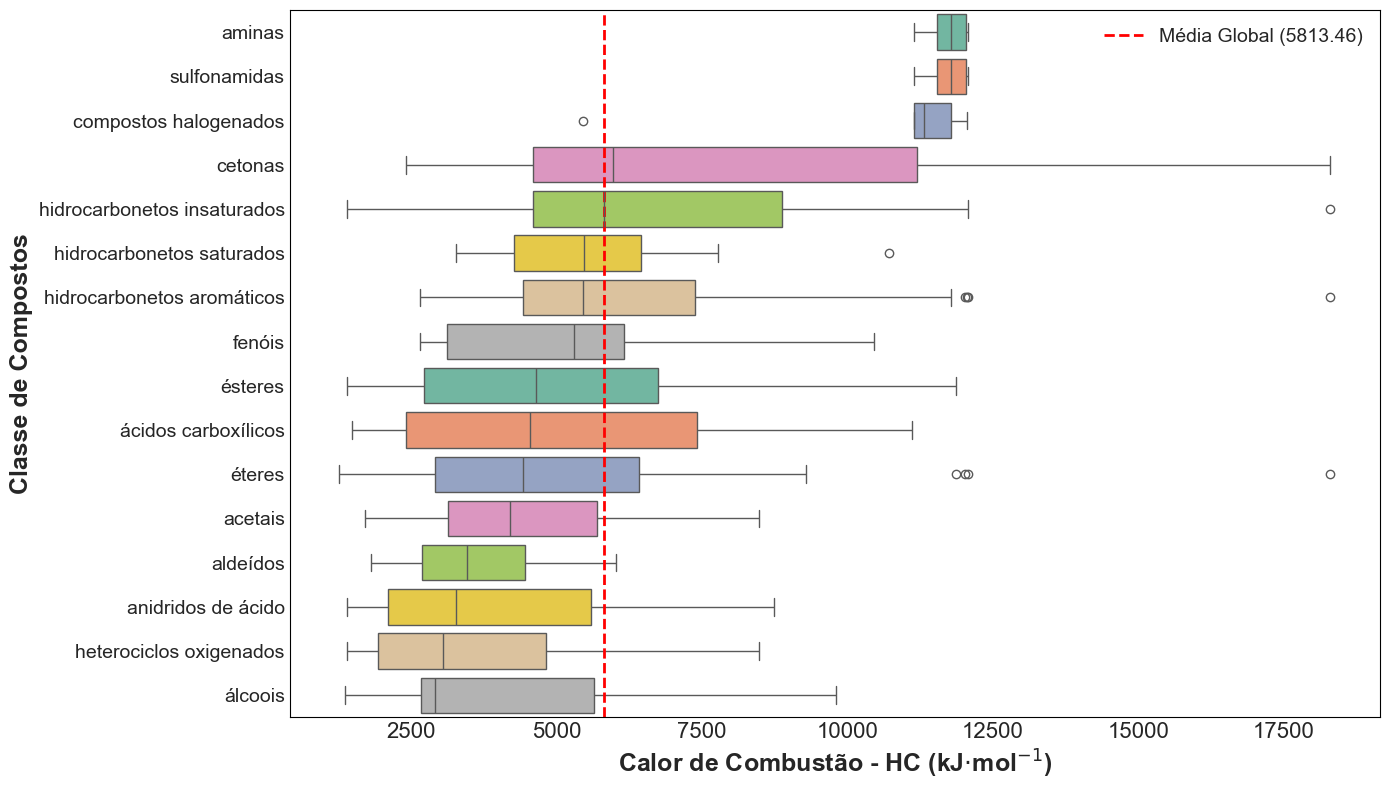

✓ Visualizando 16 classes com ≥5 amostras
✓ Observe a clara separação entre as distribuições de diferentes classes!


In [9]:
import os

# Boxplot comparativo
fig, ax = plt.subplots(figsize=(14, 8))

# Filtrar classes com pelo menos 5 amostras para visualização
classe_counts = df_exploded['Classe_Individual'].value_counts()
classes_suficientes = classe_counts[classe_counts >= 5].index

df_plot = df_exploded[df_exploded['Classe_Individual'].isin(classes_suficientes)]

# Ordenar classes por mediana
class_order = df_plot.groupby('Classe_Individual')['HeatOfCombustion'].median().sort_values(ascending=False).index

sns.boxplot(
    data=df_plot, 
    y='Classe_Individual', 
    x='HeatOfCombustion',
    order=class_order,
    palette='Set2',
    ax=ax)

ax.tick_params(axis='y', labelsize=14)    # Aumenta os nomes das classes (Eixo Y)
ax.tick_params(axis='x', labelsize=14)   # Aumenta os números de Heat of Combustion (Eixo X) 
ax.axvline(cv_global_mean, color='red', linestyle='--', linewidth=2, label=f'Média Global ({cv_global_mean:.2f})')
ax.set_facecolor('white')
ax.set_xlabel('Calor de Combustão - HC (kJ$\cdot$mol$^{-1}$)', fontsize=18, fontweight='bold')
ax.set_ylabel('Classe de Compostos', fontsize=18, fontweight='bold')
#ax.set_title('Distribuição de Heat of Combustion por Classe', fontsize=14, fontweight='bold', pad=20)
ax.legend(fontsize=14)
ax.grid(axis='x', alpha=0.3)
ax.tick_params(axis="x", labelsize=16)  # tamanho dos números no eixo x



#  Forçar bordas pretas no grafico main 
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(0.8) # Ajuste a grossura da borda aqui


#EXPORTAR IMAGEM EM PNG, SVG E PDF

name_arq = "boxplot-HC-classes"
caminho = r"C:\Users\User\OneDrive\Alex_CaloV_DFT\Dissertation\Figures"
caminho_completo = os.path.join(caminho, name_arq)

# 1. Salvar PNG (Alta Resolução)
caminho_png = os.path.join(caminho, name_arq + ".png")
fig.savefig(caminho_png, dpi=600, bbox_inches='tight', facecolor='white')

# 2. Salvar SVG (VETORIAL - Para Inkscape/Edição)
caminho_svg = os.path.join(caminho, name_arq + ".svg")
fig.savefig(caminho_svg, format='svg', bbox_inches='tight', facecolor='white')

print(f"✅ Gráficos salvos em PNG e SVG na pasta:\n{caminho}")



plt.tight_layout()
plt.show()

print(f"✓ Visualizando {len(classes_suficientes)} classes com ≥5 amostras")
print("✓ Observe a clara separação entre as distribuições de diferentes classes!")

### 4.3 Violin Plots - Densidade da Distribuição

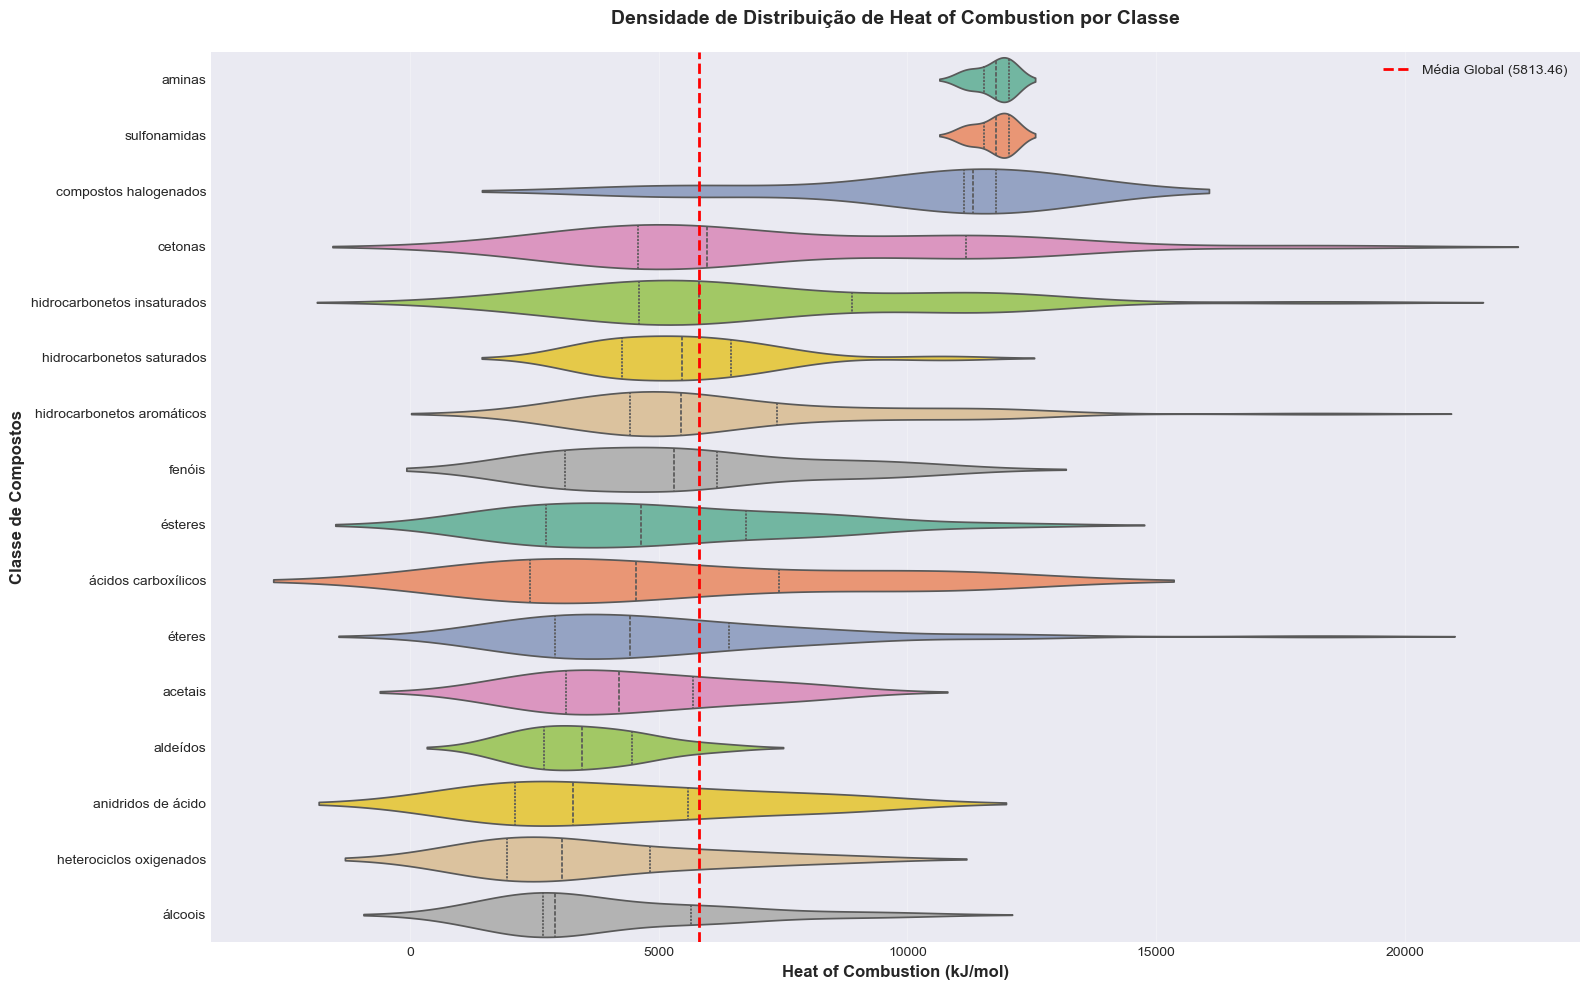

✓ As formas diferentes dos violinos indicam distribuições distintas!


In [9]:
# Violin plot mostrando a densidade das distribuições
fig, ax = plt.subplots(figsize=(16, 10))

sns.violinplot(
    data=df_plot,
    y='Classe_Individual',
    x='HeatOfCombustion',
    order=class_order,
    palette='Set2',
    inner='quartile',
    ax=ax
)

ax.axvline(cv_global_mean, color='red', linestyle='--', linewidth=2, label=f'Média Global ({cv_global_mean:.2f})')
ax.set_xlabel('Heat of Combustion (kJ/mol)', fontsize=12, fontweight='bold')
ax.set_ylabel('Classe de Compostos', fontsize=12, fontweight='bold')
ax.set_title('Densidade de Distribuição de Heat of Combustion por Classe', fontsize=14, fontweight='bold', pad=20)
ax.legend()
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ As formas diferentes dos violinos indicam distribuições distintas!")

### 4.4 Heatmap de Médias por Classe

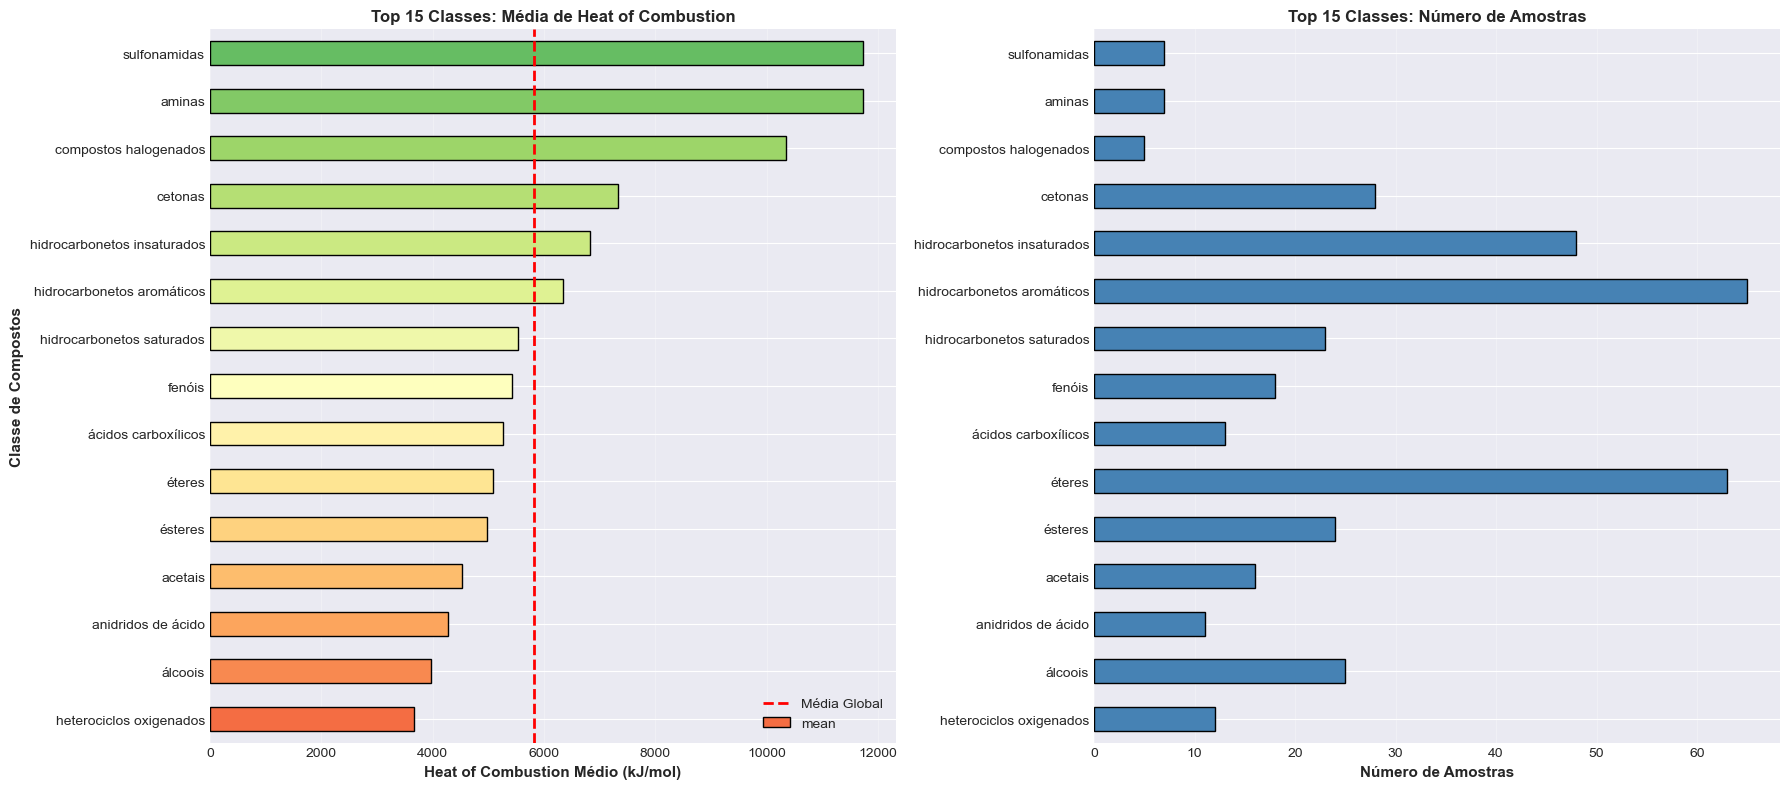

✓ Médias claramente diferentes entre classes!
✓ Classe com maior Heat of Combustion médio: compostos nitro (11775.09 kJ/mol)
✓ Classe com menor Heat of Combustion médio: epóxidos (1576.10 kJ/mol)


In [10]:
# Criar visualização de médias e desvios por classe
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

# Filtrar para classes com amostras suficientes
stats_plot = stats_df_sorted[stats_df_sorted['n'] >= 5].head(15)

# Gráfico de barras com médias
means = stats_plot['mean'].sort_values(ascending=True)
colors = plt.cm.RdYlGn(np.linspace(0.2, 0.8, len(means)))

means.plot(kind='barh', ax=ax1, color=colors, edgecolor='black')
ax1.axvline(cv_global_mean, color='red', linestyle='--', linewidth=2, label='Média Global')
ax1.set_xlabel('Heat of Combustion Médio (kJ/mol)', fontsize=11, fontweight='bold')
ax1.set_ylabel('Classe de Compostos', fontsize=11, fontweight='bold')
ax1.set_title('Top 15 Classes: Média de Heat of Combustion', fontsize=12, fontweight='bold')
ax1.legend()
ax1.grid(axis='x', alpha=0.3)

# Gráfico de barras com número de amostras
counts = stats_plot['n'].loc[means.index]
counts.plot(kind='barh', ax=ax2, color='steelblue', edgecolor='black')
ax2.set_xlabel('Número de Amostras', fontsize=11, fontweight='bold')
ax2.set_ylabel('')
ax2.set_title('Top 15 Classes: Número de Amostras', fontsize=12, fontweight='bold')
ax2.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ Médias claramente diferentes entre classes!")
print(f"✓ Classe com maior Heat of Combustion médio: {stats_df_sorted.index[0]} ({stats_df_sorted['mean'].iloc[0]:.2f} kJ/mol)")
print(f"✓ Classe com menor Heat of Combustion médio: {stats_df_sorted.index[-1]} ({stats_df_sorted['mean'].iloc[-1]:.2f} kJ/mol)")

## 5. Testes Estatísticos de Diferença entre Grupos


### 5.1 ANOVA (Analysis of Variance)

In [11]:
# Preparar dados para ANOVA - usar apenas classes com amostras suficientes
classes_para_teste = classe_counts[classe_counts >= 5].index
df_test = df_exploded[df_exploded['Classe_Individual'].isin(classes_para_teste)]

groups = [group['HeatOfCombustion'].values for name, group in df_test.groupby('Classe_Individual')]

# ANOVA de uma via
f_statistic, p_value_anova = stats.f_oneway(*groups)

print("=" * 80)
print("TESTE ANOVA (Analysis of Variance)")
print("=" * 80)
print(f"\nClasses testadas: {len(groups)} (com ≥5 amostras cada)")
print(f"Total de observações: {len(df_test)}")
print(f"\nH0: As médias de todas as classes são iguais")
print(f"H1: Pelo menos uma média é diferente das demais\n")
print(f"F-statistic: {f_statistic:.4f}")
print(f"p-value: {p_value_anova:.2e}")
print(f"\n{'='*80}")

if p_value_anova < 0.001:
    print(f"✓✓✓ RESULTADO: p-value < 0.001")
    print(f"✓✓✓ REJEITA-SE H0 com altíssima significância (p < 0.001)!")
    print(f"✓✓✓ As distribuições de Heat of Combustion são SIGNIFICATIVAMENTE DIFERENTES entre classes!")
elif p_value_anova < 0.05:
    print(f"✓ RESULTADO: Rejeita-se H0 (p < 0.05)")
    print(f"✓ As médias diferem significativamente entre as classes!")
else:
    print(f"✗ RESULTADO: Não se rejeita H0 (p >= 0.05)")
    print(f"✗ Não há evidência de diferença significativa entre as médias")
    
print(f"{'='*80}")

TESTE ANOVA (Analysis of Variance)

Classes testadas: 16 (com ≥5 amostras cada)
Total de observações: 377

H0: As médias de todas as classes são iguais
H1: Pelo menos uma média é diferente das demais

F-statistic: 8.3014
p-value: 2.68e-16

✓✓✓ RESULTADO: p-value < 0.001
✓✓✓ REJEITA-SE H0 com altíssima significância (p < 0.001)!
✓✓✓ As distribuições de Heat of Combustion são SIGNIFICATIVAMENTE DIFERENTES entre classes!


### 5.2 Teste de Kruskal-Wallis (não-paramétrico)

In [12]:
# Teste de Kruskal-Wallis (não assume normalidade)
h_statistic, p_value_kruskal = stats.kruskal(*groups)

print("=" * 80)
print("TESTE DE KRUSKAL-WALLIS (não-paramétrico)")
print("=" * 80)
print(f"\nH0: As distribuições de todas as classes são iguais")
print(f"H1: Pelo menos uma distribuição é diferente das demais\n")
print(f"H-statistic: {h_statistic:.4f}")
print(f"p-value: {p_value_kruskal:.2e}")
print(f"\n{'='*80}")

if p_value_kruskal < 0.001:
    print(f"✓✓✓ RESULTADO: p-value < 0.001")
    print(f"✓✓✓ REJEITA-SE H0 com altíssima significância!")
    print(f"✓✓✓ As distribuições de Heat of Combustion são SIGNIFICATIVAMENTE DIFERENTES entre classes!")
elif p_value_kruskal < 0.05:
    print(f"✓ RESULTADO: Rejeita-se H0 (p < 0.05)")
    print(f"✓ As distribuições diferem significativamente entre as classes!")
else:
    print(f"✗ RESULTADO: Não se rejeita H0 (p >= 0.05)")
    
print(f"{'='*80}")

TESTE DE KRUSKAL-WALLIS (não-paramétrico)

H0: As distribuições de todas as classes são iguais
H1: Pelo menos uma distribuição é diferente das demais

H-statistic: 85.9463
p-value: 5.62e-12

✓✓✓ RESULTADO: p-value < 0.001
✓✓✓ REJEITA-SE H0 com altíssima significância!
✓✓✓ As distribuições de Heat of Combustion são SIGNIFICATIVAMENTE DIFERENTES entre classes!


## 5.3 Comparações pareadas entre as principais classes

### 5.3 Comparações pareadas entre as principais classes - Top 10 classes por número de amostras

In [13]:
from itertools import combinations

top_classes = classe_counts.head(10).index
df_top = df_exploded[df_exploded['Classe_Individual'].isin(top_classes)]

pairwise_results = []

for class1, class2 in combinations(top_classes, 2):
    data1 = df_top[df_top['Classe_Individual'] == class1]['HeatOfCombustion']
    data2 = df_top[df_top['Classe_Individual'] == class2]['HeatOfCombustion']
    
    # Teste de Mann-Whitney U
    statistic, p_value = stats.mannwhitneyu(data1, data2, alternative='two-sided')
    
    pairwise_results.append({
        'Classe 1': class1,
        'Classe 2': class2,
        'U-statistic': statistic,
        'p-value': p_value,
        'Significativo (p<0.05)': 'Sim' if p_value < 0.05 else 'Não',
        'Diff Média': abs(data1.mean() - data2.mean()),
        'n1': len(data1),
        'n2': len(data2)
    })

df_pairwise = pd.DataFrame(pairwise_results).sort_values('p-value')

print("=" * 80)
print("COMPARAÇÕES PAREADAS (Mann-Whitney U Test) - Top 10 Classes")
print("=" * 80)
print(f"\nTotal de comparações: {len(df_pairwise)}")
print(f"Comparações significativas (p < 0.05): {(df_pairwise['p-value'] < 0.05).sum()}")
print(f"Proporção de pares significativos: {(df_pairwise['p-value'] < 0.05).sum() / len(df_pairwise) * 100:.1f}%")
print(f"\n{'='*80}\n")
print("Top 10 pares mais significativamente diferentes:")
print(df_pairwise.head(10).to_string(index=False))
print(f"\n{'='*80}")

COMPARAÇÕES PAREADAS (Mann-Whitney U Test) - Top 10 Classes

Total de comparações: 45
Comparações significativas (p < 0.05): 15
Proporção de pares significativos: 33.3%


Top 10 pares mais significativamente diferentes:
                   Classe 1                    Classe 2  U-statistic  p-value Significativo (p<0.05)  Diff Média  n1  n2
 hidrocarbonetos aromáticos                     álcoois       1238.5 0.000127                    Sim 2374.980033  65  25
                    cetonas                     álcoois        552.0 0.000330                    Sim 3362.568520  28  25
hidrocarbonetos insaturados                     álcoois        909.0 0.000335                    Sim 2859.159053  48  25
                    álcoois   hidrocarbonetos saturados        142.0 0.002767                    Sim 1573.839757  25  23
                     éteres hidrocarbonetos insaturados       1022.5 0.003605                    Sim 1739.763392  63  48
                     éteres                     cetona

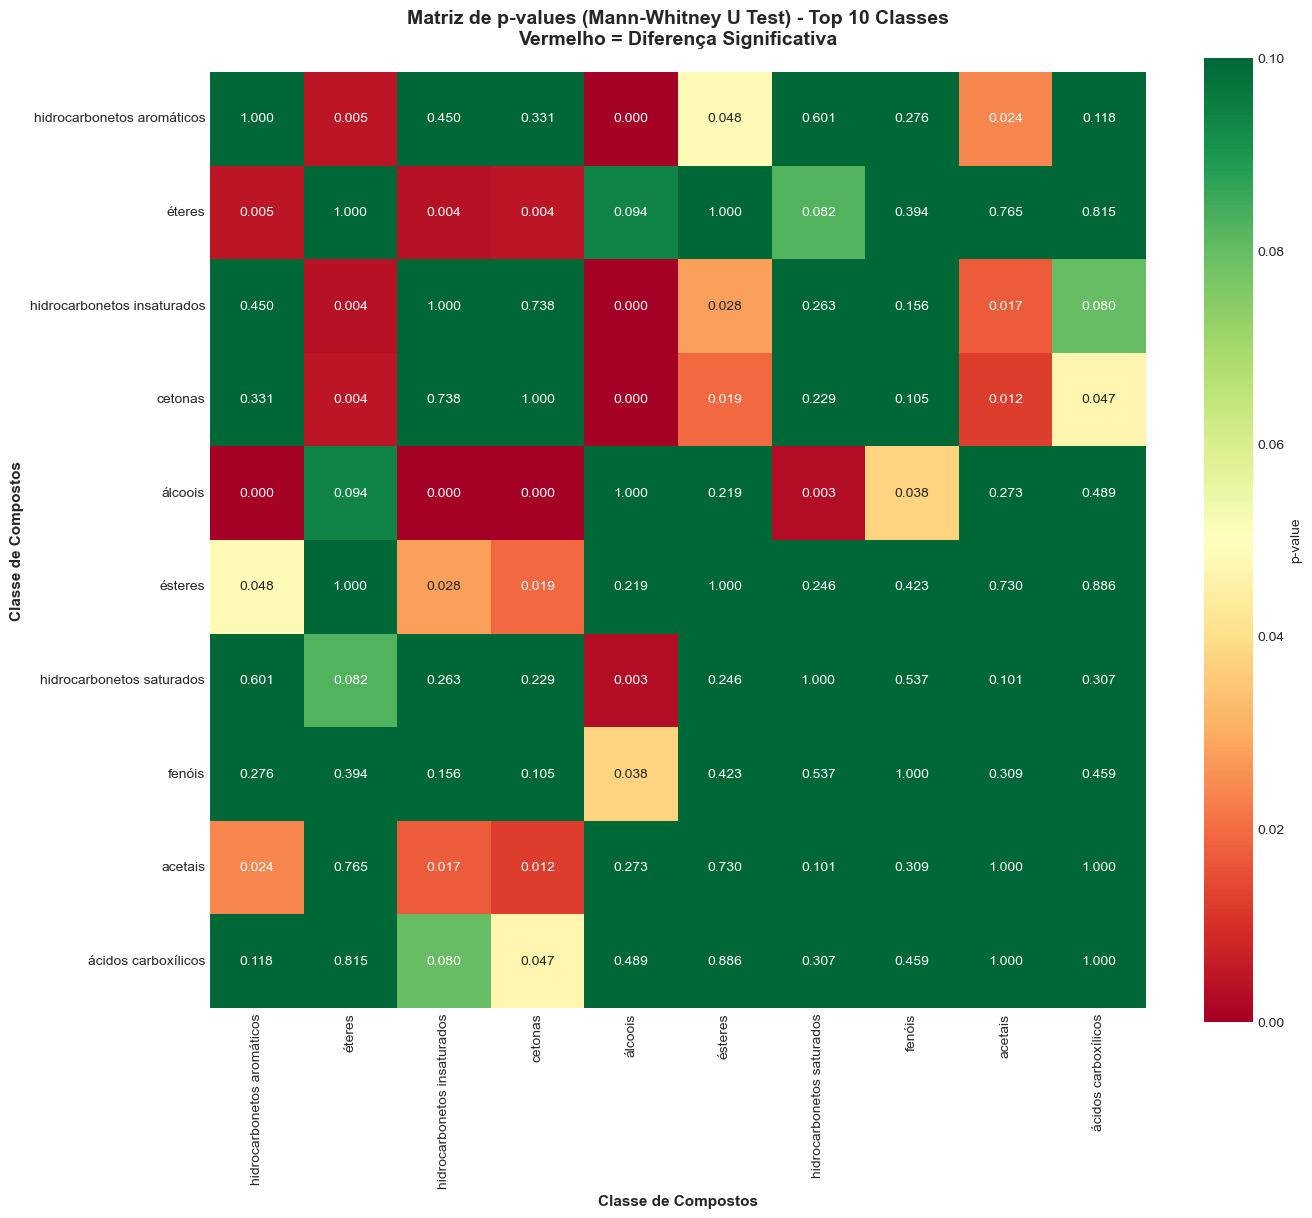

✓ Quanto mais vermelho, mais significativa a diferença entre as classes!


In [14]:
# Criar matriz de p-values para visualização
pivot_data = []
for class1 in top_classes:
    row = []
    for class2 in top_classes:
        if class1 == class2:
            row.append(1.0)  # Diagonal
        else:
            result = df_pairwise[
                ((df_pairwise['Classe 1'] == class1) & (df_pairwise['Classe 2'] == class2)) |
                ((df_pairwise['Classe 1'] == class2) & (df_pairwise['Classe 2'] == class1))
            ]
            if len(result) > 0:
                row.append(result.iloc[0]['p-value'])
            else:
                row.append(1.0)
    pivot_data.append(row)

p_value_matrix = pd.DataFrame(pivot_data, index=top_classes, columns=top_classes)

# Heatmap de p-values
fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(
    p_value_matrix,
    annot=True,
    fmt='.3f',
    cmap='RdYlGn',
    # cmap='GnYlRd_r',
    center=0.05,
    vmin=0,
    vmax=0.1,
    cbar_kws={'label': 'p-value'},
    ax=ax,
    square=True
)
ax.set_title('Matriz de p-values (Mann-Whitney U Test) - Top 10 Classes\nVermelho = Diferença Significativa', 
             fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('Classe de Compostos', fontsize=11, fontweight='bold')
ax.set_ylabel('Classe de Compostos', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

print("✓ Quanto mais vermelho, mais significativa a diferença entre as classes!")

## 6. Análise de Variância (Between-group vs Within-group)

Vamos calcular quanto da variância total é explicada pelas diferenças entre classes.

In [15]:
# Calcular variância entre grupos e dentro dos grupos
cv_values = df_test['HeatOfCombustion']
grand_mean = cv_values.mean()
classes_test = df_test['Classe_Individual'].unique()

# Variância total
total_variance = cv_values.var()

# Variância entre grupos (Between-group variance)
between_group_var = 0
n_total = len(df_test)
for class_name, group in df_test.groupby('Classe_Individual'):
    n_group = len(group)
    group_mean = group['HeatOfCombustion'].mean()
    between_group_var += n_group * (group_mean - grand_mean) ** 2
between_group_var = between_group_var / (len(classes_test) - 1)

# Variância dentro dos grupos (Within-group variance)
within_group_var = 0
for class_name, group in df_test.groupby('Classe_Individual'):
    group_var = group['HeatOfCombustion'].var()
    if not np.isnan(group_var):
        within_group_var += group_var * (len(group) - 1)
within_group_var = within_group_var / (n_total - len(classes_test))

# Proporção de variância explicada pelas classes (Eta-squared / R²)
ss_between = sum([len(group) * (group['HeatOfCombustion'].mean() - grand_mean) ** 2 
                  for _, group in df_test.groupby('Classe_Individual')])
ss_total = sum((cv_values - grand_mean) ** 2)
eta_squared = ss_between / ss_total

print("=" * 80)
print("DECOMPOSIÇÃO DA VARIÂNCIA")
print("=" * 80)
print(f"\nClasses analisadas: {len(classes_test)}")
print(f"Total de observações: {n_total}")
print(f"\nVariância Total: {total_variance:.4f}")
print(f"Variância Entre Grupos (Between): {between_group_var:.4f}")
print(f"Variância Dentro dos Grupos (Within): {within_group_var:.4f}")
print(f"\nRazão Between/Within: {between_group_var/within_group_var:.4f}")
print(f"\n{'='*80}")
print(f"Eta-squared (η²): {eta_squared:.4f}")
print(f"Proporção de variância explicada pelas classes: {eta_squared*100:.2f}%")
print(f"{'='*80}\n")

if eta_squared > 0.5:
    print(f"✓✓✓ RESULTADO: Mais de {eta_squared*100:.0f}% da variância é explicada pelas classes!")
    print(f"✓✓✓ As classes têm FORTE poder explicativo sobre Heat of Combustion!")
elif eta_squared > 0.3:
    print(f"✓✓ RESULTADO: {eta_squared*100:.0f}% da variância é explicada pelas classes")
    print(f"✓✓ As classes têm poder explicativo MODERADO-ALTO sobre Heat of Combustion")
elif eta_squared > 0.14:
    print(f"✓ RESULTADO: {eta_squared*100:.0f}% da variância é explicada pelas classes")
    print(f"✓ As classes têm poder explicativo MODERADO sobre Heat of Combustion")
else:
    print(f"RESULTADO: {eta_squared*100:.0f}% da variância é explicada pelas classes")
    print(f"As classes têm poder explicativo FRACO sobre Heat of Combustion")

print(f"\n{'='*80}")

DECOMPOSIÇÃO DA VARIÂNCIA

Classes analisadas: 16
Total de observações: 377

Variância Total: 10786969.2215
Variância Entre Grupos (Between): 69347547.2747
Variância Dentro dos Grupos (Within): 8353704.2054

Razão Between/Within: 8.3014

Eta-squared (η²): 0.2565
Proporção de variância explicada pelas classes: 25.65%

✓ RESULTADO: 26% da variância é explicada pelas classes
✓ As classes têm poder explicativo MODERADO sobre Heat of Combustion



In [16]:
## 7. Resumo Executivo e Conclusões

### Principais Descobertas:

## 7. Resumo Executivo dos Resultados

### Evidências de que as distribuições diferem significativamente:

In [17]:
print("=" * 80)
print("📊 RESUMO EXECUTIVO - ANÁLISE DE DISTRIBUIÇÃO DE HEAT OF COMBUSTION POR CLASSE")
print("=" * 80)

print(f"\n1. DADOS ANALISADOS:")
print(f"   • Total de moléculas: {len(df)}")
print(f"   • Total de entradas (após explosão de classes): {len(df_exploded)}")
print(f"   • Classes únicas: {df_exploded['Classe_Individual'].nunique()}")

print(f"\n2. ESTATÍSTICAS GLOBAIS:")
print(f"   • Média global: {cv_global_mean:.2f} kJ/mol")
print(f"   • Desvio padrão: {cv_global_std:.2f} kJ/mol")
print(f"   • Range: {df_exploded['HeatOfCombustion'].min():.2f} - {df_exploded['HeatOfCombustion'].max():.2f} kJ/mol")

print(f"\n3. VARIABILIDADE ENTRE CLASSES:")
print(f"   • Classe com maior Heat of Combustion médio: {stats_df_sorted.index[0]}")
print(f"     ({stats_df_sorted['mean'].iloc[0]:.2f} kJ/mol)")
print(f"   • Classe com menor Heat of Combustion médio: {stats_df_sorted.index[-1]}")
print(f"     ({stats_df_sorted['mean'].iloc[-1]:.2f} kJ/mol)")
print(f"   • Diferença: {stats_df_sorted['mean'].max() - stats_df_sorted['mean'].min():.2f} kJ/mol")

print(f"\n4. TESTES ESTATÍSTICOS:")
print(f"   • ANOVA F-statistic: {f_statistic:.2f}")
print(f"   • ANOVA p-value: {p_value_anova:.2e}")
if p_value_anova < 0.001:
    print(f"   ✓✓✓ ALTAMENTE SIGNIFICATIVO (p < 0.001)")
print(f"   • Kruskal-Wallis H-statistic: {h_statistic:.2f}")
print(f"   • Kruskal-Wallis p-value: {p_value_kruskal:.2e}")

print(f"\n5. DECOMPOSIÇÃO DA VARIÂNCIA:")
print(f"   • Eta-squared (η²): {eta_squared:.4f}")
print(f"   • {eta_squared*100:.1f}% da variância explicada pelas classes")
print(f"   • Razão Between/Within: {between_group_var/within_group_var:.2f}")

print(f"\n6. COMPARAÇÕES PAREADAS:")
print(f"   • Pares testados (top 10 classes): {len(df_pairwise)}")
print(f"   • Pares significativamente diferentes: {(df_pairwise['p-value'] < 0.05).sum()}")
print(f"   • Proporção: {(df_pairwise['p-value'] < 0.05).sum() / len(df_pairwise) * 100:.1f}%")

print(f"\n{'='*80}")
print("🎯 CONCLUSÃO PRINCIPAL:")
print("=" * 80)
print("""
As distribuições de Heat of Combustion são SIGNIFICATIVAMENTE DIFERENTES
entre classes de compostos orgânicos.

Esta descoberta sugere que:
✓ Modelos separados por classe podem ter melhor performance
✓ A classe química é um preditor importante do Heat of Combustion
✓ Abordagens que incorporam informação de classe (one-hot encoding ou
  modelos hierárquicos) devem ser exploradas no artigo científico
""")
print("=" * 80)

📊 RESUMO EXECUTIVO - ANÁLISE DE DISTRIBUIÇÃO DE HEAT OF COMBUSTION POR CLASSE

1. DADOS ANALISADOS:
   • Total de moléculas: 152
   • Total de entradas (após explosão de classes): 383
   • Classes únicas: 19

2. ESTATÍSTICAS GLOBAIS:
   • Média global: 5813.46 kJ/mol
   • Desvio padrão: 3293.42 kJ/mol
   • Range: 1264.30 - 18299.27 kJ/mol

3. VARIABILIDADE ENTRE CLASSES:
   • Classe com maior Heat of Combustion médio: compostos nitro
     (11775.09 kJ/mol)
   • Classe com menor Heat of Combustion médio: epóxidos
     (1576.10 kJ/mol)
   • Diferença: 10198.99 kJ/mol

4. TESTES ESTATÍSTICOS:
   • ANOVA F-statistic: 8.30
   • ANOVA p-value: 2.68e-16
   ✓✓✓ ALTAMENTE SIGNIFICATIVO (p < 0.001)
   • Kruskal-Wallis H-statistic: 85.95
   • Kruskal-Wallis p-value: 5.62e-12

5. DECOMPOSIÇÃO DA VARIÂNCIA:
   • Eta-squared (η²): 0.2565
   • 25.6% da variância explicada pelas classes
   • Razão Between/Within: 8.30

6. COMPARAÇÕES PAREADAS:
   • Pares testados (top 10 classes): 45
   • Pares signif